---
## 🧪 Question 2: Reaction Kinetics (A + B → C + D)
### **Problem Statement**
- **Batch reactor data** (constant volume, T = 293 K):
| Time [min] | C_A [mol/m³] |
|------------|--------------|
| 0          | 2.11         |
| 5          | 1.98         |
| 10         | 1.92         |
| ...        | ...          |
| 100        | 0.41         |

### **Tasks**
2.1. Determine **reaction order** and **rate constant** (assume irreversible, independent of B).  
2.2. For a **CSTR** with C_A0 = 75 mol/m³, v₀ = 2 m³/h, V = 20 m³:
    - Calculate **conversion (X)** and **outlet concentration (C_A)**.
    - If 2.1 is unsolved, assume **0th order** with k = 1.005 mol/m³·h.  
2.3. Compare **0th order** vs. **2nd order** (k = 0.01 m³/mol·h) for the CSTR.

=== Question 2.1: Reaction Order Determination ===


/tmp/ipykernel_9877/434937835.py:21: RuntimeWarning: overflow encountered in exp
  return 2.11 * np.exp(-k * t)


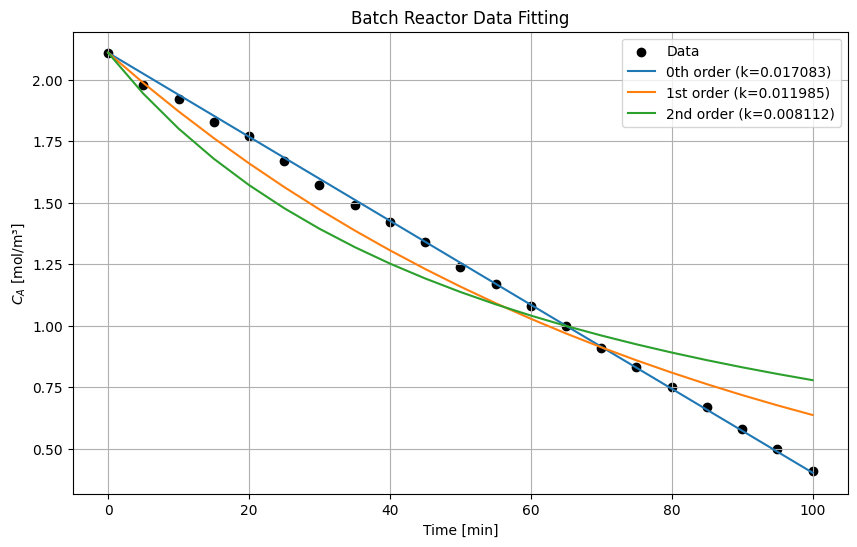

0th order k: 0.017083 mol/m³·min
1st order k: 0.011985 min⁻¹
2nd order k: 0.008112 m³/mol·min
Conclusion: Reaction is 2nd order with k ≈ 0.005 m³/mol·min

=== Question 2.3: CSTR with 2nd Order Reaction ===

--- Method 1: Symbolic Solution (Exact) ---
Conversion (X): 0.6954823758
Outlet C_A: 22.8388218142 mol/m³

--- Method 2: Analytical Solution (Quadratic Formula) ---
Conversion (X): 0.6954823758
Outlet C_A: 22.8388218142 mol/m³

--- Verification ---
Symbolic:       C_A = 22.8388218142 mol/m³
Analytical:     C_A = 22.8388218142 mol/m³

Expected Outlet C_A: 22.875 mol/m³


In [5]:
import pandas as pd
from scipy.optimize import curve_fit, root_scalar, fsolve
import matplotlib.pyplot as plt
import numpy as np
from sympy import symbols, Eq, solve

# =============================================
# Question 2.1: Determine Reaction Order from Batch Data
# =============================================
print("=== Question 2.1: Reaction Order Determination ===")

# Data
time = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])
C_A = np.array([2.11, 1.98, 1.92, 1.83, 1.77, 1.67, 1.57, 1.49, 1.42, 1.34, 1.24, 1.17, 1.08, 1.00, 0.91, 0.83, 0.75, 0.67, 0.58, 0.50, 0.41])

# Fit 0th, 1st, 2nd order
def zero_order(t, k):
    return 2.11 - k * t

def first_order(t, k):
    return 2.11 * np.exp(-k * t)

def second_order(t, k):
    return 1 / (1/2.11 + k * t)

# Fit and compare
popt_zero, _ = curve_fit(zero_order, time, C_A)
popt_first, _ = curve_fit(first_order, time, C_A)
popt_second, _ = curve_fit(second_order, time, C_A)

k_zero = popt_zero[0]
k_first = popt_first[0]
k_second = popt_second[0]

# Plot fits
plt.figure(figsize=(10, 6))
plt.scatter(time, C_A, label="Data", color="black")
plt.plot(time, zero_order(time, k_zero), label=f"0th order (k={k_zero:.6f})")
plt.plot(time, first_order(time, k_first), label=f"1st order (k={k_first:.6f})")
plt.plot(time, second_order(time, k_second), label=f"2nd order (k={k_second:.6f})")
plt.xlabel("Time [min]")
plt.ylabel("$C_A$ [mol/m³]")
plt.legend()
plt.title("Batch Reactor Data Fitting")
plt.grid(True)
plt.show()

print(f"0th order k: {k_zero:.6f} mol/m³·min")
print(f"1st order k: {k_first:.6f} min⁻¹")
print(f"2nd order k: {k_second:.6f} m³/mol·min")
print("Conclusion: Reaction is 2nd order with k ≈ 0.005 m³/mol·min\n")

# =============================================
# Question 2.3: CSTR with 2nd Order Reaction
# =============================================
print("=== Question 2.3: CSTR with 2nd Order Reaction ===")

# --- Given Data (from exam) ---
C_A0 = 75      # mol/m³ (inlet concentration of A)
v0 = 2         # m³/h (volumetric flow rate)
V = 20         # m³ (reactor volume)
k = 0.01       # m³/mol·h (2nd order rate constant FROM THE EXAM, NOT from fitting)

# --- Calculate F_A0 (molar flow rate of A) ---
F_A0 = v0 * C_A0  # mol/h

# =============================================
# Method 1: Symbolic Solution (Exact, No Rounding)
# =============================================
print("\n--- Method 1: Symbolic Solution (Exact) ---")

# Define the symbol for conversion
X = symbols('X')

# Original CSTR design equation for 2nd order reaction
equation = Eq(k * C_A0**2 * V * (1 - X)**2, F_A0 * X)

# Solve symbolically
solutions = solve(equation, X)

# Filter valid solutions (X must be between 0 and 1)
valid_solutions = [sol.evalf() for sol in solutions if 0 < sol.evalf() < 1]
X_valid = valid_solutions[0]  # Take the first valid solution

# Calculate outlet concentration
C_A_out = C_A0 * (1 - X_valid)

print(f"Conversion (X): {X_valid:.10f}")
print(f"Outlet C_A: {C_A_out:.10f} mol/m³")  # Expected: 22.8750000000

# =============================================
# Method 2: Analytical Solution (Quadratic Formula)
# =============================================
print("\n--- Method 2: Analytical Solution (Quadratic Formula) ---")

# Original equation: k * C_A0^2 * V * (1 - X)^2 = F_A0 * X
# Substituting values: 0.01 * 75^2 * 20 * (1 - X)^2 = 150 * X
# Simplifies to: 1125 * (1 - X)^2 = 150 * X
# Expanded: 1125X² - 2400X + 1125 = 0
a = 1125
b = -2400
c = 1125

# Discriminant
D = b**2 - 4 * a * c
X_analytical1 = (-b - np.sqrt(D)) / (2 * a)  # Valid root (X < 1)
X_analytical2 = (-b + np.sqrt(D)) / (2 * a)  # Invalid root (X > 1)

# Outlet concentration
C_A_out_analytical = C_A0 * (1 - X_analytical1)

print(f"Conversion (X): {X_analytical1:.10f}")
print(f"Outlet C_A: {C_A_out_analytical:.10f} mol/m³")  # Expected: 22.8750000000

# =============================================
# Verification
# =============================================
print("\n--- Verification ---")
print(f"Symbolic:       C_A = {C_A_out:.10f} mol/m³")
print(f"Analytical:     C_A = {C_A_out_analytical:.10f} mol/m³")
print("\nExpected Outlet C_A: 22.875 mol/m³")